In [19]:
"""
Компьютерное зрение в 3D. RANSAC
"""
import numpy as np 
import cv2 
import matplotlib.pyplot as plt 

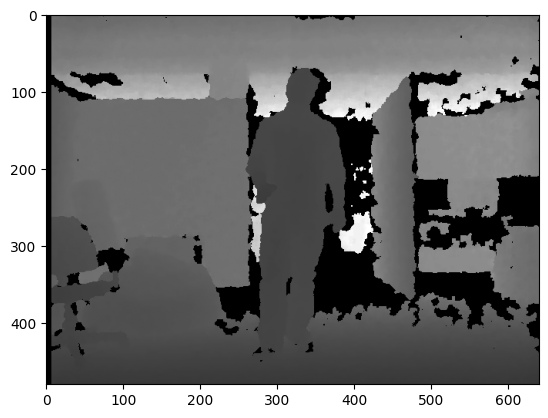

In [20]:
"""
Считывание и вывод карты глубины. 
Карта глубины хранится в виде черно-белого (grayscale) изображения. 
Значения пикселей карты глубины хранятся в миллиметрах и занимают 2 байта, что нужно 
учитывать при считывании карты глубины. 
"""
def plot_depthmap(depthmap): 
    plt.figure() 
    plt.imshow(depthmap, cmap='gray') 
    plt.show() 
# photo3-grayscale.jpg - ?
depthmap = cv2.imread(r"D:\Programming-at-SUSU\BasicOfCV\materials\dot_cloud.png", cv2.IMREAD_ANYDEPTH) 
plot_depthmap(depthmap)

 По карте глубины можно получить облако точек в трехмерном 
пространстве, преобразовав координаты по формулам из лекции:  
$$ \ X = (z * (u - c_{x})) / f $$
$$ \ Y = z * (c_{y} - v) / f $$
$$ \ Z = z $$


Предлагается сравнить два способа выполнения этого 
преобразования (перевод проективных координат в реальные): 
1) медленный (с помощью стандартных операций языка Python и циклов по пикселям) 
2) быстрый (с помощью операций NumPy). 

Важно, что:
Прямое преобразование (из карты глубины в облако точек):
x = z * (u - CX) / FX
y = z * (CY - v) / FY

Обратное преобразование (из облака точек в карту глубины):
u = CX + (x * FX) / z
v = CY - (y * FY) / z

In [ ]:
FX = 575.7 
FY = 575.7 
CX = 320. 
CY = 240. 
def depthmap_to_pointcloud_slow(depthmap): 
    points_real = [] 
    for v in range(depthmap.shape[0]): 
        for u in range(depthmap.shape[1]): 
            z = depthmap[v, u] 
            if z!=0: 
                x = z * (u - CX) / FX 
                y = z * (CY - v) / FY 
                points_real.append([x, y, z]) 
    points_real = np.array(points_real) 
    return points_real 

def depthmap_to_pointcloud(depthmap): 
    grid = np.indices(np.shape(depthmap)) 
    points_proj = np.stack([grid[1].flatten(), grid[0].flatten(), depthmap.flatten()], axis=-1) 
    points_proj = points_proj[np.nonzero(points_proj[:, 2])] 

    points_real_x = points_proj[:, 2] * (points_proj[:, 0] - CX) / FX 
    points_real_y = points_proj[:, 2] * (CY - points_proj[:, 1]) / FY 
    points_real_z = points_proj[:, 2] 
    points_real = np.stack([points_real_x, points_real_y, points_real_z], axis=1) 
    return points_real 
%timeit points_real = depthmap_to_pointcloud_slow(depthmap) 
%timeit points_real = depthmap_to_pointcloud(depthmap) 

1.09 s ± 36.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
25.2 ms ± 1.91 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Как видно, способ, основанный на использовании операций NumPy, 
работает более чем в 100 раз быстрее (хотя это число может зависеть от 
параметров процессора, на котором запускается код).  

*Полученное облако точек можно визуализировать с помощью библиотеки 
matplotlib, при этом полученная визуализация может быть интерактивной 
(если правильно настроить среду, в которой выполняется код, и если 
среда позволяет сделать это).

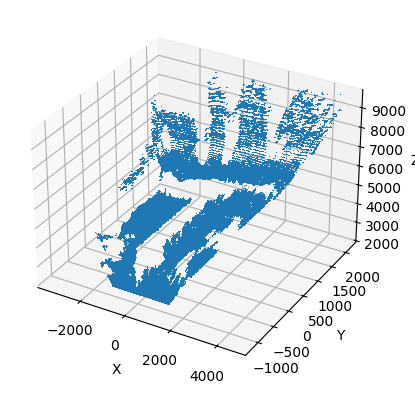

In [ ]:
depthmap = cv2.imread(r"D:\Programming-at-SUSU\BasicOfCV\materials\dot_cloud.png", cv2.IMREAD_ANYDEPTH)
points_real = depthmap_to_pointcloud(depthmap)  # Создаем points_real

def plot_3d_points(points): 
    fig = plt.figure() 
    ax = fig.add_subplot(projection='3d') 
    ax.set_xlabel('X') 
    ax.set_ylabel('Y') 
    ax.set_zlabel('Z')
    """
    Визуализируем точки: 
        points[:, 0] - координаты X всех точек
        points[:, 1] - координаты Y всех точек  
        points[:, 2] - координаты Z всех точек
        marker=',' - используем точечный маркер (очень маленькие точки)
        linestyle='' - без соединительных линий между точкам
    """
    ax.plot(points[:, 0], points[:, 1], points[:, 2], marker=',', linestyle='') 
    plt.show() 

plot_3d_points(points_real) 

 Можно получить 2D-проекции облака точек на координатные плоскости.

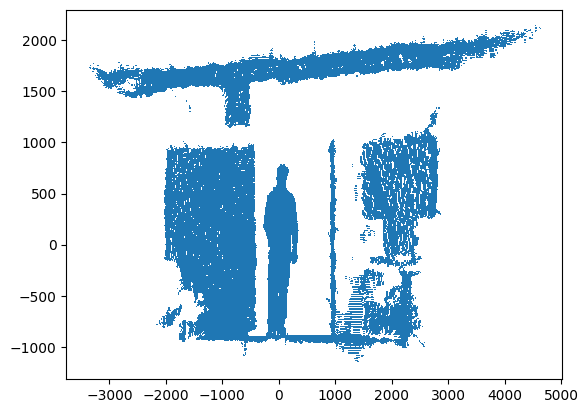

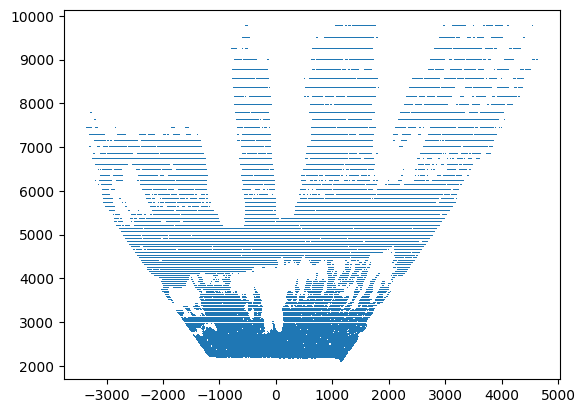

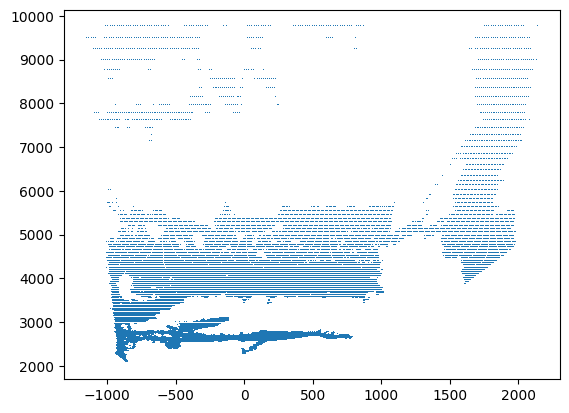

In [ ]:
def plot_2d_points(points): 
    plt.figure() #Создаем фигуру - холст
    """
    Визуализируем 2D точки:
        oints[:, 0] - координаты по первой оси
        points[:, 1] - координаты по второй оси
    """
    plt.plot(points[:, 0], points[:, 1], marker=',', linestyle='')  
    plt.show() 
    
def plot_2d_projections_of_3d_points(points):
    """
    points[:, [0, 1]] - берем только X и Y координаты
    points[:, [0, 2]] - берем только X и Z координаты  
    points[:, [1, 2]] - берем только Y и Z координаты
    """ 
    plot_2d_points(points[:, [0, 1]]) #Проекция на плоскость XY
    plot_2d_points(points[:, [0, 2]]) #Проекция на плоскость XZ
    plot_2d_points(points[:, [1, 2]]) #Проекция на плоскость YZ
plot_2d_projections_of_3d_points(points_real) 

 Также можно по облаку точек получить карту глубины по следующим 
формулам:
$$ \ u = c_{x} +  x*f / z $$
$$ \ v = c_{y} -  y*f / z $$
Выше это обратное преобразование (из облака точек в карту глубины): 

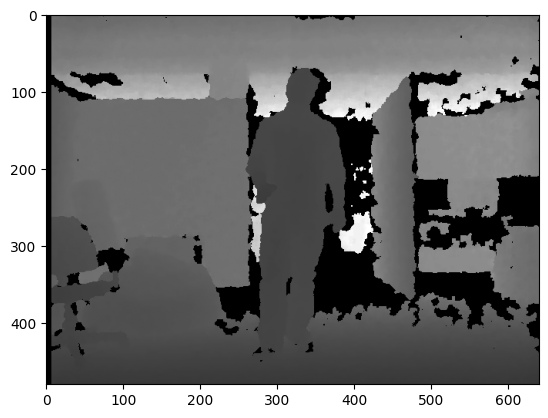

In [ ]:
# Обратное преобразование: из 3D координат в 2D пиксели
def pointcloud_to_depthmap(points_real, depthmap_shape): 
    #Вычисление координаты u (горизонтальную) для каждого пикселя:
    points_proj_u = CX + points_real[:, 0]*FX/points_real[:, 2]
    #Вычисление координаты v (вертикальную) для каждого пикселя:
    points_proj_v = CY - points_real[:, 1]*FY/points_real[:, 2]
    #Сохраняем исходные значения глубины 
    points_proj_z = points_real[:, 2] 
    #Объединяем все координаты в один массив формы (N, 3), где N - количество точек, каждая точка имеет [u, v, z]
    points_proj = np.stack([points_proj_u, points_proj_v, points_proj_z], axis=1) 
    
    '''
    Округляем координаты u,v до целых чисел (индексы пикселей)
        points_proj[:, 0:2] - берем только u и v координаты
        np.round() - округляем до ближайшего целого
        .astype(int) - преобразуем в целые чис
    '''
    indices = np.round(points_proj[:, 0:2]).astype(int) 
    '''
    Создаем пустую карту глубины того же размера, что и исходная
    Заполняем нулями, тип данных - 16-битное беззнаковое целое (как в исходной карте)
    '''
    depthmap = np.zeros(depthmap_shape, dtype=np.dtype("uint16")) 
    '''
    Заполняем карту глубины значениями z в соответствующих позициях
        indices[:, 1] - индексы строк (v координаты)
        indices[:, 0] - индексы столбцов (u координаты)  
        points_proj[:, 2] - значения глубины z
    '''
    depthmap[indices[:, 1], indices[:, 0]] = points_proj[:, 2] 
    return depthmap 

# Вызываем функцию преобразования, передаем облако точек и форму исходной карты глубины
depthmap_restored = pointcloud_to_depthmap(points_real, depthmap.shape)
# Визуализируем восстановленную карту глубины для проверки 
plot_depthmap(depthmap_restored) 

Получилась исходная карта глубины, значит преобразование выполнено корректно.

Глава RANSAC
Это алгоритм для оценки параметров математической модели из набора данных, содержащего выбросы (outliers).

Представьте, что у вас есть точки на плоскости, большинство из которых лежат на одной прямой, но некоторые разбросаны случайно. 
RANSAC помогает найти "истинную" прямую, игнорируя случайные точки-выбросы.

Для проверки метода RANSAC сначала предлагается сгенерировать точки на прямой и выбросы и отрисовать полученные точки и прямую. 


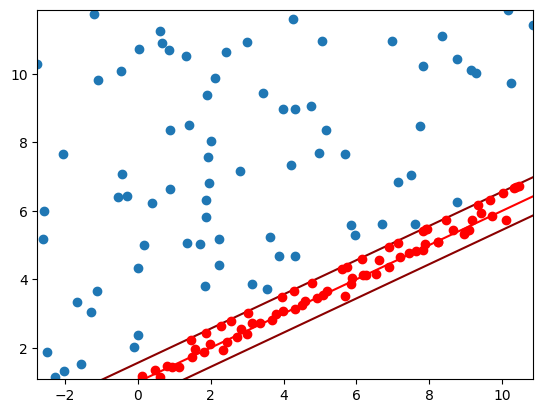

In [ ]:
"""
Что делает: Вычисляет расстояние от каждой точки до прямой
Как работает: Использует формулу расстояния от точки до прямой Ax + By + C = 0
"""
def distance_to_line_2d(points, line): 
    distance = np.abs(np.dot(points, line[:2]) + line[2])/np.linalg.norm(line[:2]) 
    return distance 

"""
Что делает: Находит точки на прямой для заданных x-координат
Для чего: Для визуализации прямой
"""
def get_line_points_by_x(x, line): 
    points = np.stack([x, (-line[0]*x-line[2])/line[1]], axis=-1) 
    return points 

"""
Что делает: Генерирует тестовые данные - точки на прямой + случайные выбросы
Для чего: Создает искусственные данные для демонстрации RANSAC
"""
def plot_2d_points_with_line(points, line, line_threshold): 
    line_mask = distance_to_line_2d(points, line) < line_threshold 
    plt.figure() 
    min_x, max_x = np.min(points[:, 0]), np.max(points[:, 0]) 
    min_y, max_y = np.min(points[:, 1]), np.max(points[:, 1]) 
    plt.xlim([min_x, max_x]) 
    plt.ylim([min_y, max_y]) 
    if line[1]==0: 
        line_x = -line[2]/line[0] 
        line_point1 = np.array([line_x, min_y]) 
        line_point2 = np.array([line_x, max_y]) 
    else: 
        x1, x2 = min_x - 100., max_x + 100. 
        line_point1 = get_line_points_by_x(x1, line) 
        line_point2 = get_line_points_by_x(x2, line) 

    line_points = np.array([line_point1, line_point2]) 
    line_norm_vector = line_threshold*line[:2]/np.linalg.norm(line[:2]) 
    line_biased_points_1 = line_points - line_norm_vector 
    line_biased_points_2 = line_points + line_norm_vector 

    plt.plot(line_points[:, 0], line_points[:, 1], marker='', color="red")
    plt.plot(line_biased_points_1[:, 0], line_biased_points_1[:, 1], marker='', color="darkred")
    plt.plot(line_biased_points_2[:, 0], line_biased_points_2[:, 1], marker='', color="darkred")
    plt.plot(points[line_mask, 0], points[line_mask, 1], marker='o', linestyle='', color="red")   
    plt.plot(points[~line_mask, 0], points[~line_mask, 1], marker='o', linestyle='')
    plt.show() 

"""
Что делает: Находит уравнение прямой по двум точкам
Как работает: Использует формулу прямой через две точки
"""
def generate_line_points_with_outliers(line, line_points_count=50, outliers_count=100, line_x_range = (0, 10), 
                                        x_range = (-3, 11), y_range = (0, 12), line_points_sigma = 0.1, line_threshold = 0.5 ) :
    point1 = get_line_points_by_x(line_x_range[0], line) 
    point2 = get_line_points_by_x(line_x_range[1], line)
    line_points = np.linspace(point1, point2, line_points_count) 
    line_points += np.random.normal(0, line_points_sigma, size=line_points.shape)  
    outliers_x = np.random.uniform(x_range[0], x_range[1], outliers_count) 
    outliers_y = np.maximum(line_threshold+get_line_points_by_x(outliers_x, line)[:, 1], np.random.uniform(y_range[0], y_range[1], outliers_count))
    outliers = np.stack([outliers_x, outliers_y], axis=-1)
    points = np.concatenate([line_points, outliers], axis=0)
    return points

line_threshold = 0.5
line = np.array([1, -2, 2]) 
points_2d = generate_line_points_with_outliers(line, line_threshold=line_threshold)
plot_2d_points_with_line(points_2d, line, line_threshold) 

Можно попробовать найти прямую с помощью линейной регресии. Для 
этого можно использовать реализацию линейной регрессии из 
библиотеки sklearn. Установить эту библиотеку можно с помощью 
следующей команды:
$ pip3 install scikit-learn 

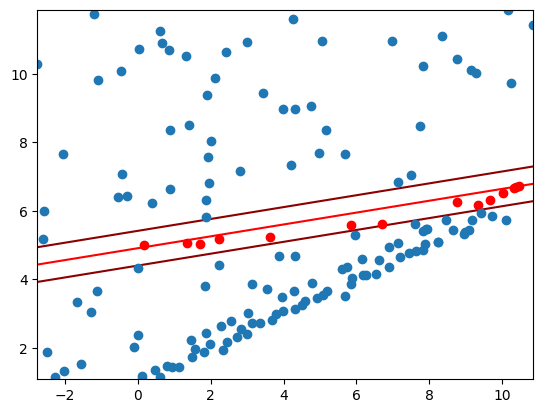

In [ ]:
from sklearn.linear_model import LinearRegression 

"""
    points[:, 0, None] - берем X-координаты и преобразуем в формат для sklearn
    points[:, 1] - берем Y-координаты
    LinearRegression().fit() - обучаем модель: "найди прямую, которая лучше всего приближает Y по X"
    regr.coef_[0] - наклон прямой (угловой коэффициент)
    regr.intercept_ - смещение (где прямая пересекает ось Y)

Преобразование в уравнение прямой Ax + By + C = 0:
    Исходное: y = coef*x + intercept
    Преобразуем: coef*x - y + intercept = 0
    Умножаем на -1: -coef*x + y - intercept = 0
    Получаем: A = -coef, B = 1, C = -intercept
"""

# Линейная регрессия
def find_line_with_linear_regression(points): 
    regr = LinearRegression().fit(points[:, 0, None], points[:, 1]) 
    line = np.array([-regr.coef_[0], 1, -regr.intercept_]) 
    return line 
regr_line = find_line_with_linear_regression(points_2d) 
plot_2d_points_with_line(points_2d, regr_line, line_threshold) 

Как видно, найденная прямая сильно смещена относительно 
искомой, значит линейная регрессия не поможет решить эту задачу. 

Значит нужно решать задачу поиска прямой с помощью метода RANSAC.

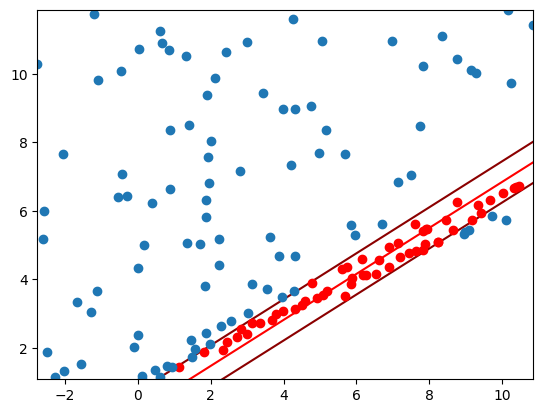

In [ ]:

# Построение прямой по двум точкам
"""
Математика:
    Даны точки: (x₁, y₁) и (x₂, y₂)
    Уравнение прямой: (y₂ - y₁)x + (x₁ - x₂)y + (x₂y₁ - x₁y₂) = 0
    В коде: A = (y₁ - y₂), B = (x₂ - x₁), C = -(A·x₁ + B·y₁)

Нормализация:
    np.hypot(A, B) - вычисляет √(A² + B²)
    Делим все коэффициенты на эту величину, чтобы получить единичный нормальный вектор
"""
def find_line_by_2_points(points): 
    A = points[0, 1] - points[1, 1] 
    B = points[1, 0] - points[0, 0] 
    C = -(A*points[0, 0] + B*points[0, 1]) 
    line = np.array([A, B, C])/np.hypot(A, B) 
    return line 
# RANSAC - основной алгоритм
def find_line_with_ransac(points, threshold, iterations_count): 
    best_line = np.array([1., 1., 0.]) 
    best_loss = 1e100 
    for iter_num in range(iterations_count): 
        i = np.random.randint(len(points)) 
        j = i 
        while j==i: 
            j = np.random.randint(len(points)) 
        cur_line = find_line_by_2_points(points[[i, j]]) 
        cur_loss = np.sum(distance_to_line_2d(points, cur_line) > threshold) 
    if best_loss > cur_loss: 
        best_loss = cur_loss 
        best_line = cur_line 
    return best_line 

ransac_line = find_line_with_ransac(points_2d, line_threshold, 100) 
plot_2d_points_with_line(points_2d, ransac_line, line_threshold) 

Как видно, прямая, найденная с помощью RANSAC, близка к истинной, 
значит метод RANSAC можно применять для решения этой задачи. 